# 07 — Cross-Subreddit Comparison: r/GradAdmissions, r/MSCS, r/MBA

Loads pre-computed pipeline outputs from all three subreddits and produces a side-by-side
comparison of:
- Anchor post volume and distress characteristics
- Panel coverage and exposure rates
- PSM-matched DiD ATT estimates (primary analysis)
- Pre/post mh_score distributions
- Pairwise statistical tests for difference between subreddit ATT estimates

**Prerequisites:** Run NB01–NB06 for each subreddit via `run_pipeline.py` before running this notebook.

**Inputs:**
- `data/processed/gradadmissions/*.parquet`
- `data/processed/mscs/*.parquet`
- `data/processed/mba/*.parquet`

**Outputs:**
- `figures/fig_att_comparison.png` — forest plot: ATT coefficients for all subreddits
- `figures/fig_mhscore_distributions.png` — boxplot: pre/post mh_score by subreddit
- `figures/fig_anchor_comparison.png` — anchor post characteristics side by side
- `data/processed/comparison_summary.parquet` — all key metrics in one table

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

ROOT    = Path('..').resolve()
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

SUBREDDITS = {
    'gradadmissions': ROOT / 'data' / 'processed' / 'gradadmissions',
    'mscs':           ROOT / 'data' / 'processed' / 'mscs',
    'mba':            ROOT / 'data' / 'processed' / 'mba',
}

REQUIRED = [
    'panel_scores.parquet',
    'anchor_posts.parquet',
    'exposure_labels.parquet',
    'user_community_breadth.parquet',
]

print('Checking required files...')
all_ok = True
for sr, ddir in SUBREDDITS.items():
    for fname in REQUIRED:
        exists = (ddir / fname).exists()
        status = 'OK' if exists else 'MISSING'
        if not exists:
            all_ok = False
        print(f'  r/{sr}/{fname}: {status}')

if not all_ok:
    print('\nSome files are missing — run NB01–NB06 for each subreddit first.')
else:
    print('\nAll files present.')

Checking required files...
  r/gradadmissions/panel_scores.parquet: OK
  r/gradadmissions/anchor_posts.parquet: OK
  r/gradadmissions/exposure_labels.parquet: OK
  r/gradadmissions/user_community_breadth.parquet: OK
  r/mscs/panel_scores.parquet: OK
  r/mscs/anchor_posts.parquet: OK
  r/mscs/exposure_labels.parquet: OK
  r/mscs/user_community_breadth.parquet: OK
  r/mba/panel_scores.parquet: OK
  r/mba/anchor_posts.parquet: OK
  r/mba/exposure_labels.parquet: OK
  r/mba/user_community_breadth.parquet: OK

All files present.


## 1) Panel and anchor post summary

In [ ]:
summary_rows = []

for sr, ddir in SUBREDDITS.items():
    panel    = pd.read_parquet(ddir / 'panel_scores.parquet')
    anchors  = pd.read_parquet(ddir / 'anchor_posts.parquet')
    exposure = pd.read_parquet(ddir / 'exposure_labels.parquet')

    cycles_here = sorted(int(c) for c in exposure['cycle'].dropna().unique())
    for cycle in cycles_here:
        pc = panel[panel['cycle'] == cycle]
        ec = exposure[exposure['cycle'] == cycle]
        ac = anchors[anchors['cycle'].isin([cycle, float(cycle)])]
        summary_rows.append({
            'subreddit':              f'r/{sr}',
            'cycle':                  cycle,
            'total_panel_users':      len(ec),
            'n_exposed':              int(ec['exposed'].sum()),
            'n_unexposed':            int((~ec['exposed']).sum()),
            'exposure_rate_pct':      round(100 * ec['exposed'].mean(), 2),
            'n_users_w_pre_post':     len(pc),
            'n_anchor_posts':         len(ac),
            'mean_anchor_mh_score':   round(ac['mean_mh_score'].mean(), 4) if len(ac) else np.nan,
            'mean_anchor_score':      round(ac['score'].mean(), 1) if len(ac) else np.nan,
            'mean_anchor_n_comments': round(ac['num_comments'].mean(), 1) if len(ac) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)
print('=== Panel & Anchor Post Summary ===')
print(summary_df.to_string(index=False))

## 2) Anchor post characteristics comparison

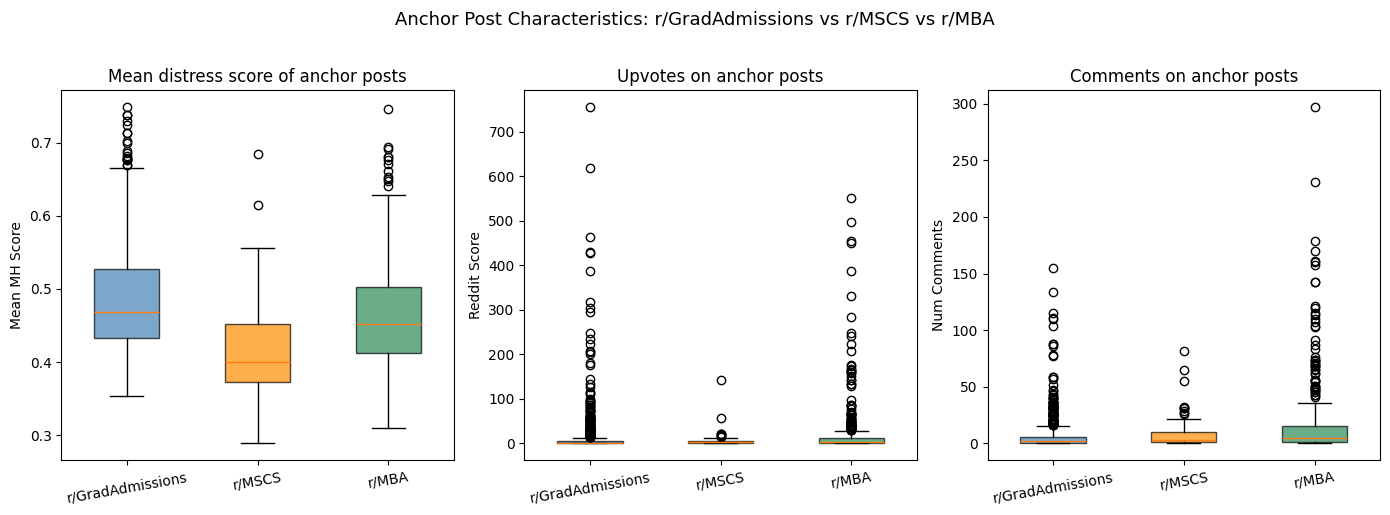

r/gradadmissions: 997 anchor posts | mean_mh=0.4869 | score=13.2 | comments=6.4
r/mscs: 100 anchor posts | mean_mh=0.4150 | score=6.5 | comments=8.2
r/mba: 471 anchor posts | mean_mh=0.4630 | score=22.0 | comments=16.0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

anchor_data = {}
for sr, ddir in SUBREDDITS.items():
    anchor_data[sr] = pd.read_parquet(ddir / 'anchor_posts.parquet')

metrics = [
    ('mean_mh_score', 'Mean MH Score', 'Mean distress score of anchor posts'),
    ('score',         'Reddit Score',  'Upvotes on anchor posts'),
    ('num_comments',  'Num Comments',  'Comments on anchor posts'),
]

colors = {'gradadmissions': 'steelblue', 'mscs': 'darkorange', 'mba': 'seagreen'}
labels = {'gradadmissions': 'r/GradAdmissions', 'mscs': 'r/MSCS', 'mba': 'r/MBA'}

for ax, (col, ylabel, title) in zip(axes, metrics):
    data_to_plot = [anchor_data[sr][col].dropna().values for sr in list(SUBREDDITS)]
    bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.5)
    for patch, sr in zip(bp['boxes'], list(SUBREDDITS)):
        patch.set_facecolor(colors[sr])
        patch.set_alpha(0.7)
    ax.set_xticklabels([labels[sr] for sr in list(SUBREDDITS)], rotation=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.suptitle('Anchor Post Characteristics: ' + ' vs '.join(labels[sr] for sr in SUBREDDITS),
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_anchor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

for sr in SUBREDDITS:
    a = anchor_data[sr]
    print(f'r/{sr}: {len(a):,} anchor posts | mean_mh={a["mean_mh_score"].mean():.4f} | '
          f'score={a["score"].mean():.1f} | comments={a["num_comments"].mean():.1f}')

## 3) PSM + DiD helper functions (reused from NB06)

In [4]:
CALIPER       = 0.05
MATCH_FEATURES = ['pre_mh_score', 'log1p_n_posts_pre']


def psm_match(df, features, caliper):
    """1:1 nearest-neighbor PSM; returns (matched_author_set, n_pairs, clean_df)."""
    clean = df.dropna(subset=features).copy()
    X = StandardScaler().fit_transform(clean[features])
    y = clean['exposed'].astype(int).values
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X, y)
    clean['pscore'] = lr.predict_proba(X)[:, 1]
    exp_df   = clean[clean['exposed']].reset_index(drop=True)
    unexp_df = clean[~clean['exposed']].reset_index(drop=True)
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(unexp_df[['pscore']])
    dists, idxs = nn.kneighbors(exp_df[['pscore']])
    matched_authors = set()
    for i, (dist, idx) in enumerate(zip(dists.flatten(), idxs.flatten())):
        if dist <= caliper:
            matched_authors.add(exp_df.loc[i, 'author'])
            matched_authors.add(unexp_df.loc[idx, 'author'])
    n_pairs = sum(1 for d in dists.flatten() if d <= caliper)
    return matched_authors, n_pairs, clean


def build_long_df(panel_sub, matched_authors, cycle):
    """Reshape matched panel rows to long format (period 0/1)."""
    rows = []
    for _, row in panel_sub[panel_sub['author'].isin(matched_authors)].iterrows():
        base = {'author': row['author'], 'cycle': cycle, 'exposed': int(row['exposed'])}
        rows.append({**base, 'period': 0, 'mh_score': row['pre_mh_score'],  'n_posts': row['pre_n_posts']})
        rows.append({**base, 'period': 1, 'mh_score': row['post_mh_score'], 'n_posts': row['post_n_posts']})
    df = pd.DataFrame(rows)
    df['period_x_exposed'] = df['period'] * df['exposed']
    df['log1p_n_posts']    = np.log1p(df['n_posts'])
    return df


def run_did(df, label=''):
    """Run DiD regression; return fitted model."""
    m = smf.ols(
        'mh_score ~ period + exposed + period_x_exposed + log1p_n_posts',
        data=df.dropna(subset=['mh_score'])
    ).fit(cov_type='HC3')
    coef = m.params['period_x_exposed']
    pval = m.pvalues['period_x_exposed']
    ci   = m.conf_int().loc['period_x_exposed']
    sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    if label:
        print(f'  {label:<25}  DiD={coef:+.4f} [{ci[0]:+.4f}, {ci[1]:+.4f}]  p={pval:.4f} {sig}  n={int(m.nobs):,}')
    return m


print('Helper functions defined.')

Helper functions defined.


## 4) Run PSM + DiD for each subreddit

In [ ]:
all_results  = {}   # sr -> {models, long_df, n_pairs_by_cycle}
all_long_dfs = {}   # sr -> combined long_df (all cycles)

for sr, ddir in SUBREDDITS.items():
    print(f'\n=== r/{sr} ===')
    panel   = pd.read_parquet(ddir / 'panel_scores.parquet')
    breadth_path = ddir / 'user_community_breadth.parquet'
    if breadth_path.exists():
        breadth = pd.read_parquet(breadth_path)
        panel = panel.merge(breadth[['author', 'community_breadth', 'community_breadth_log']],
                            on='author', how='left')
    panel['log1p_n_posts_pre'] = np.log1p(panel['pre_n_posts'])

    cycles_here = sorted(int(c) for c in panel['cycle'].dropna().unique())

    matched_by_cycle = {}
    n_pairs_by_cycle = {}
    long_rows_all    = []

    for cycle in cycles_here:
        sub = panel[panel['cycle'] == cycle].copy()
        authors, n_pairs, _ = psm_match(sub, MATCH_FEATURES, CALIPER)
        matched_by_cycle[cycle] = authors
        n_pairs_by_cycle[cycle] = n_pairs
        print(f'  Cycle {cycle}: {n_pairs:,} matched pairs')
        long_rows_all.append(build_long_df(sub, authors, cycle))

    long_df = pd.concat(long_rows_all, ignore_index=True)
    all_long_dfs[sr] = long_df

    print(f'  DiD results (HC3 SEs):')
    models = {}
    for cycle in cycles_here:
        models[cycle] = run_did(long_df[long_df['cycle'] == cycle], f'Cycle {cycle}')

    pool = long_df.copy()
    pool['cycle_fe'] = pool['cycle'].astype(str)
    m_pool = smf.ols(
        'mh_score ~ period + exposed + period_x_exposed + log1p_n_posts + C(cycle_fe)',
        data=pool.dropna(subset=['mh_score'])
    ).fit(cov_type='HC3')
    models['pooled'] = m_pool

    coef_p = m_pool.params['period_x_exposed']
    pval_p = m_pool.pvalues['period_x_exposed']
    ci_p   = m_pool.conf_int().loc['period_x_exposed']
    sig_p  = '***' if pval_p < 0.001 else ('**' if pval_p < 0.01 else ('*' if pval_p < 0.05 else 'n.s.'))
    print(f'  {"Pooled (+cycle FE)":<25}  DiD={coef_p:+.4f} [{ci_p[0]:+.4f}, {ci_p[1]:+.4f}]  p={pval_p:.4f} {sig_p}  n={int(m_pool.nobs):,}')

    all_results[sr] = {'models': models, 'long_df': long_df, 'n_pairs': n_pairs_by_cycle, 'cycles': cycles_here}

## 5) ATT coefficient comparison plot (forest plot)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

sr_colors  = {'gradadmissions': 'steelblue',  'mscs': 'darkorange', 'mba': 'seagreen'}
sr_labels  = {'gradadmissions': 'r/GradAdmissions', 'mscs': 'r/MSCS', 'mba': 'r/MBA'}

# Use union of all cycles across subreddits so plot shows everything
all_cycles = sorted({c for sr in SUBREDDITS for c in all_results[sr]['cycles']})
spec_keys  = all_cycles + ['pooled']
spec_names = [f'Cycle {c}' for c in all_cycles] + ['Pooled']
n_specs    = len(spec_keys)
n_srs      = len(SUBREDDITS)
offset     = 0.22   # vertical offset between subreddits at same spec

sr_list = list(SUBREDDITS)
for si, sr in enumerate(sr_list):
    models = all_results[sr]['models']
    y_positions = [i + (si - (n_srs - 1) / 2) * offset for i in range(n_specs)]
    coefs, lo, hi, y_valid = [], [], [], []
    for yp, key in zip(y_positions, spec_keys):
        if key not in models:
            continue
        m  = models[key]
        c  = m.params['period_x_exposed']
        ci = m.conf_int().loc['period_x_exposed']
        coefs.append(c)
        lo.append(ci[0])
        hi.append(ci[1])
        y_valid.append(yp)
    ax.errorbar(
        coefs, y_valid,
        xerr=[np.array(coefs) - np.array(lo), np.array(hi) - np.array(coefs)],
        fmt='o', color=sr_colors[sr], label=sr_labels[sr],
        capsize=5, linewidth=2, markersize=8,
    )

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(range(n_specs))
ax.set_yticklabels(spec_names, fontsize=11)
ax.set_xlabel('DiD estimate (period × exposed)  95% CI', fontsize=11)
ax.set_title('ATT Coefficient Comparison: ' + ' vs '.join(sr_labels[sr] for sr in sr_list), fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_att_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6) Pre/post mh_score distributions

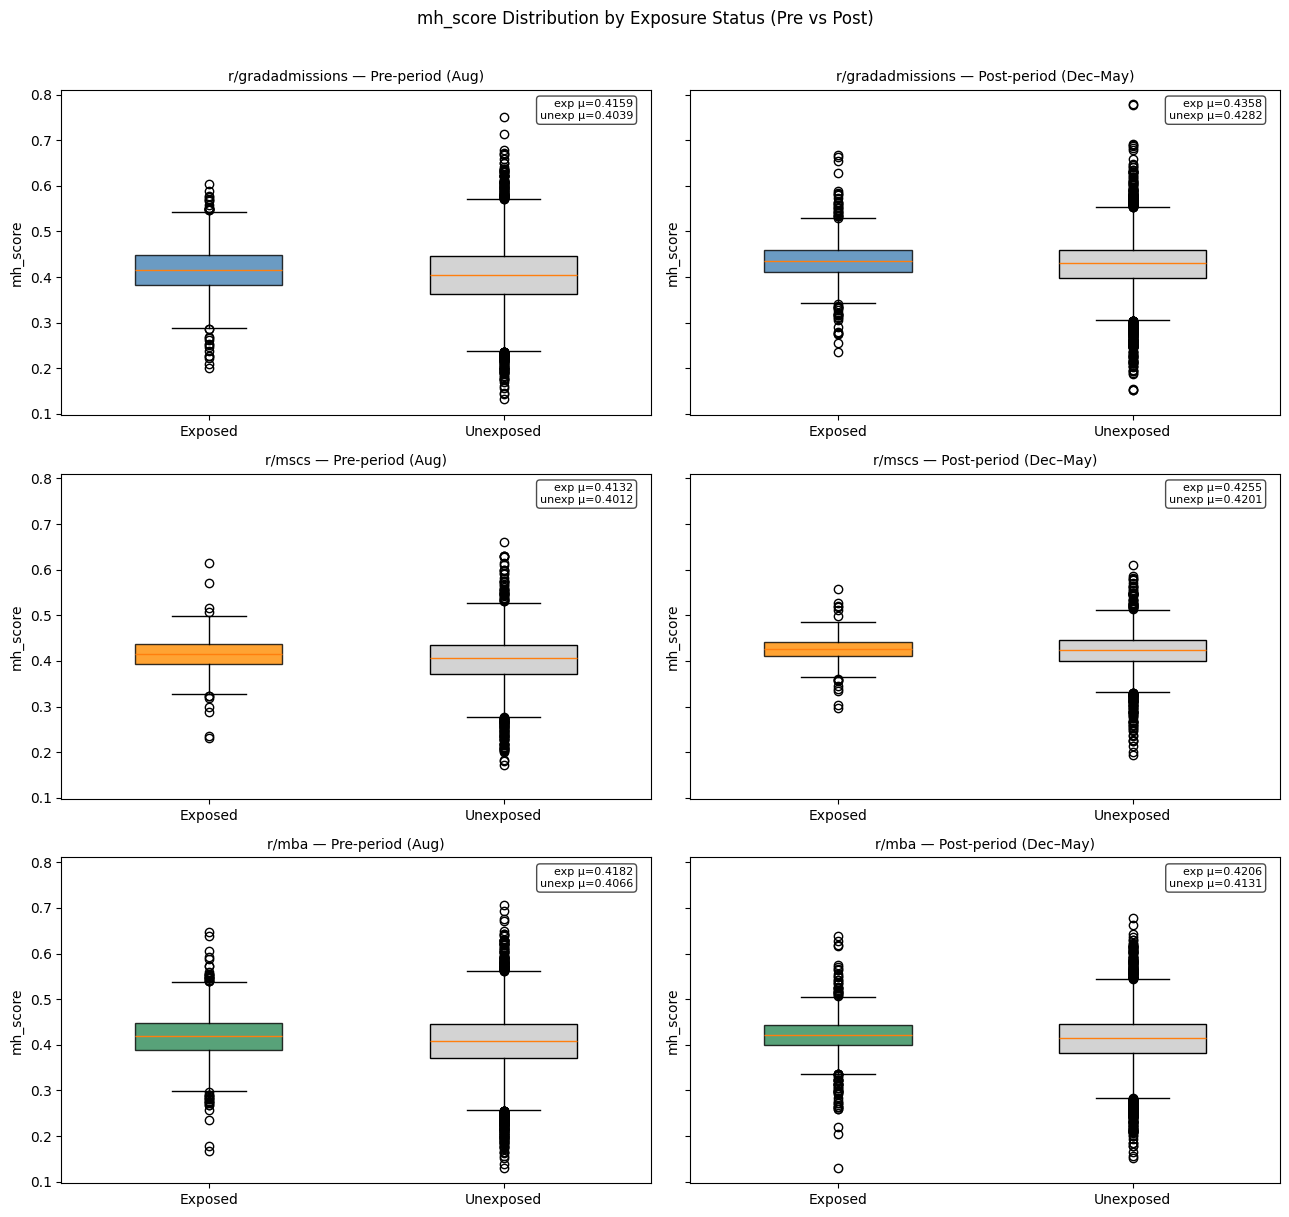

In [7]:
n_srs = len(SUBREDDITS)
fig, axes = plt.subplots(n_srs, 2, figsize=(13, 4 * n_srs), sharey=True)

for row_idx, sr in enumerate(SUBREDDITS):
    ddir  = SUBREDDITS[sr]
    panel = pd.read_parquet(ddir / 'panel_scores.parquet')
    color = sr_colors[sr]

    for col_idx, (period_col, period_label) in enumerate(
        [('pre_mh_score', 'Pre-period (Aug)'), ('post_mh_score', 'Post-period (Dec–May)')]
    ):
        ax = axes[row_idx][col_idx]
        exp_vals   = panel[panel['exposed']  ][period_col].dropna()
        unexp_vals = panel[~panel['exposed'] ][period_col].dropna()
        bp = ax.boxplot([exp_vals, unexp_vals], patch_artist=True,
                        labels=['Exposed', 'Unexposed'], widths=0.5)
        bp['boxes'][0].set_facecolor(color)
        bp['boxes'][0].set_alpha(0.8)
        bp['boxes'][1].set_facecolor('lightgray')
        ax.set_title(f'r/{sr} — {period_label}', fontsize=10)
        ax.set_ylabel('mh_score')
        ax.text(0.97, 0.97,
                f'exp μ={exp_vals.mean():.4f}\nunexp μ={unexp_vals.mean():.4f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('mh_score Distribution by Exposure Status (Pre vs Post)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_mhscore_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7) Statistical test: are the ATT estimates significantly different between subreddits?

Uses a Z-test on the ATT coefficients for each pairwise combination of subreddits:
`Z = (coef_A - coef_B) / sqrt(se_A^2 + se_B^2)`

Runs for every per-cycle spec present in both subreddits plus Pooled, across all pairwise combinations.

In [ ]:
from itertools import combinations

print('=== Z-test: Pairwise Difference in ATT between subreddits ===')
print()

rows_ztest = []
for spec_key, spec_name in zip(spec_keys, spec_names):
    print(f'── {spec_name} ──')
    for sr_a, sr_b in combinations(list(SUBREDDITS), 2):
        if spec_key not in all_results[sr_a]['models'] or spec_key not in all_results[sr_b]['models']:
            continue
        m_a = all_results[sr_a]['models'][spec_key]
        m_b = all_results[sr_b]['models'][spec_key]

        coef_a = m_a.params['period_x_exposed']
        coef_b = m_b.params['period_x_exposed']
        # HC3 standard errors
        se_a = m_a.bse['period_x_exposed']
        se_b = m_b.bse['period_x_exposed']

        diff    = coef_a - coef_b
        se_diff = np.sqrt(se_a**2 + se_b**2)
        z_stat  = diff / se_diff
        p_val   = 2 * (1 - stats.norm.cdf(abs(z_stat)))
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))

        print(f'  r/{sr_a} vs r/{sr_b}: '
              f'ATT_A={coef_a:+.4f} (SE={se_a:.4f})  '
              f'ATT_B={coef_b:+.4f} (SE={se_b:.4f})  '
              f'diff={diff:+.4f}  Z={z_stat:+.3f}  p={p_val:.4f} {sig}')

        rows_ztest.append({
            'spec':    spec_name,
            'sr_a':    f'r/{sr_a}',
            'sr_b':    f'r/{sr_b}',
            'att_a':   round(coef_a, 4),
            'se_a':    round(se_a,   4),
            'att_b':   round(coef_b, 4),
            'se_b':    round(se_b,   4),
            'diff':    round(diff,   4),
            'z_stat':  round(z_stat, 3),
            'p_val':   round(p_val,  4),
            'sig':     sig,
        })
    print()

ztest_df = pd.DataFrame(rows_ztest)
print('=== Full pairwise Z-test table ===')
print(ztest_df.to_string(index=False))

## 8) Comprehensive summary table

In [ ]:
comparison_rows = []

for sr, ddir in SUBREDDITS.items():
    panel    = pd.read_parquet(ddir / 'panel_scores.parquet')
    anchors  = pd.read_parquet(ddir / 'anchor_posts.parquet')
    exposure = pd.read_parquet(ddir / 'exposure_labels.parquet')
    models   = all_results[sr]['models']
    n_pairs  = all_results[sr]['n_pairs']
    cycles_here = all_results[sr]['cycles']

    for cycle in cycles_here:
        m   = models[cycle]
        ec  = exposure[exposure['cycle'] == cycle]
        ac  = anchors[anchors['cycle'].isin([cycle, float(cycle)])]
        coef = m.params['period_x_exposed']
        pval = m.pvalues['period_x_exposed']
        ci   = m.conf_int().loc['period_x_exposed']
        comparison_rows.append({
            'subreddit':         f'r/{sr}',
            'cycle':              cycle,
            'n_panel_users':      len(ec),
            'n_exposed':          int(ec['exposed'].sum()),
            'n_matched_pairs':    n_pairs[cycle],
            'n_anchor_posts':     len(ac),
            'mean_anchor_mh':     round(ac['mean_mh_score'].mean(), 4) if len(ac) else np.nan,
            'att_coef':           round(coef, 4),
            'att_ci_lo':          round(ci[0], 4),
            'att_ci_hi':          round(ci[1], 4),
            'att_pval':           round(pval, 4),
        })

    # Pooled row
    m_pool = models['pooled']
    coef_p = m_pool.params['period_x_exposed']
    pval_p = m_pool.pvalues['period_x_exposed']
    ci_p   = m_pool.conf_int().loc['period_x_exposed']
    comparison_rows.append({
        'subreddit':         f'r/{sr}',
        'cycle':              'pooled',
        'n_panel_users':      len(exposure),
        'n_exposed':          int(exposure['exposed'].sum()),
        'n_matched_pairs':    sum(n_pairs.values()),
        'n_anchor_posts':     len(anchors),
        'mean_anchor_mh':     round(anchors['mean_mh_score'].mean(), 4),
        'att_coef':           round(coef_p, 4),
        'att_ci_lo':          round(ci_p[0], 4),
        'att_ci_hi':          round(ci_p[1], 4),
        'att_pval':           round(pval_p, 4),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df['cycle'] = comparison_df['cycle'].astype(str)

print('=== Full Comparison Summary ===')
print(comparison_df.to_string(index=False))

# Save
OUT_PATH = ROOT / 'data' / 'processed' / 'comparison_summary.parquet'
comparison_df.to_parquet(OUT_PATH, index=False)
print(f'\nSaved comparison_summary.parquet → {OUT_PATH}')

## 9) Combined Pooled DiD (all subreddits + cycles)

Stacks the three matched panels into a single regression with subreddit and cycle fixed effects.
This is the headline cross-community result — each subreddit individually is underpowered to
detect a ~0.006 effect, but pooling gives a precision-weighted estimate across ~5,500 matched
users and three admission cycles.

```
mh_score ~ period + exposed + period×exposed + log1p_n_posts + C(subreddit) + C(cycle)
```

In [ ]:
# ── Stack all matched panels ────────────────────────────────────────────────
combined_frames = []
for sr in SUBREDDITS:
    df = all_long_dfs[sr].copy()
    df['subreddit'] = sr
    combined_frames.append(df)

combined = pd.concat(combined_frames, ignore_index=True)
combined['cycle_str'] = combined['cycle'].astype(str)
combined['period_x_exposed'] = combined['period'] * combined['exposed']

print(f'Combined matched panel: {combined["author"].nunique():,} users | {len(combined):,} obs')
print(f'Exposed users: {combined[combined["exposed"]==1]["author"].nunique():,}')
print()

# ── Main pooled regression (subreddit + cycle FE) ───────────────────────────
m_combined = smf.ols(
    'mh_score ~ period + exposed + period_x_exposed + log1p_n_posts + C(subreddit) + C(cycle_str)',
    data=combined.dropna(subset=['mh_score'])
).fit(cov_type='HC3')

coef = m_combined.params['period_x_exposed']
pval = m_combined.pvalues['period_x_exposed']
ci   = m_combined.conf_int().loc['period_x_exposed']
sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
print(f'=== COMBINED POOLED DiD (subreddit + cycle FE) ===')
print(f'  ATT = {coef:+.4f}  p = {pval:.4f} {sig}  CI = [{ci[0]:+.4f}, {ci[1]:+.4f}]  N = {int(m_combined.nobs):,}')

# ── Per subreddit (cycle FE only) ───────────────────────────────────────────
print()
print('--- Per subreddit (cycle FE) ---')
for sr in SUBREDDITS:
    sub = combined[combined['subreddit'] == sr].dropna(subset=['mh_score'])
    m2 = smf.ols(
        'mh_score ~ period + exposed + period_x_exposed + log1p_n_posts + C(cycle_str)',
        data=sub
    ).fit(cov_type='HC3')
    c2 = m2.params['period_x_exposed']
    p2 = m2.pvalues['period_x_exposed']
    ci2 = m2.conf_int().loc['period_x_exposed']
    s2 = '***' if p2 < 0.001 else ('**' if p2 < 0.01 else ('*' if p2 < 0.05 else 'n.s.'))
    print(f'  r/{sr:<18}  ATT={c2:+.4f}  p={p2:.4f} {s2}  CI=[{ci2[0]:+.4f},{ci2[1]:+.4f}]  N={int(m2.nobs):,}')

# ── Per cycle (subreddit FE only) ───────────────────────────────────────────
print()
print('--- Per cycle (subreddit FE) ---')
for cycle in sorted(combined['cycle'].unique()):
    sub = combined[combined['cycle'] == cycle].dropna(subset=['mh_score'])
    m3 = smf.ols(
        'mh_score ~ period + exposed + period_x_exposed + log1p_n_posts + C(subreddit)',
        data=sub
    ).fit(cov_type='HC3')
    c3 = m3.params['period_x_exposed']
    p3 = m3.pvalues['period_x_exposed']
    ci3 = m3.conf_int().loc['period_x_exposed']
    s3 = '***' if p3 < 0.001 else ('**' if p3 < 0.01 else ('*' if p3 < 0.05 else 'n.s.'))
    print(f'  Cycle {cycle}  ATT={c3:+.4f}  p={p3:.4f} {s3}  CI=[{ci3[0]:+.4f},{ci3[1]:+.4f}]  N={int(m3.nobs):,}')

# ── Per distress dimension ───────────────────────────────────────────────────
print()
print('--- Per distress dimension (pooled all subreddits + cycles) ---')

# need anx/dep/str in combined — rebuild with dimension scores
combined_dim_frames = []
for sr, ddir in SUBREDDITS.items():
    panel_sr = pd.read_parquet(ddir / 'panel_scores.parquet')
    long_sr  = all_long_dfs[sr].copy()
    # map pre/post dimension scores back via (author, cycle, period)
    pre_dim  = panel_sr[['author','cycle','pre_anx_score','pre_dep_score','pre_str_score']].copy()
    post_dim = panel_sr[['author','cycle','post_anx_score','post_dep_score','post_str_score']].copy()
    pre_dim['period']  = 0
    post_dim['period'] = 1
    pre_dim  = pre_dim.rename(columns={'pre_anx_score':'anx','pre_dep_score':'dep','pre_str_score':'str_'})
    post_dim = post_dim.rename(columns={'post_anx_score':'anx','post_dep_score':'dep','post_str_score':'str_'})
    dim_long = pd.concat([pre_dim, post_dim], ignore_index=True)
    merged   = long_sr.merge(dim_long, on=['author','cycle','period'], how='left')
    merged['subreddit'] = sr
    combined_dim_frames.append(merged)

combined_dim = pd.concat(combined_dim_frames, ignore_index=True)
combined_dim['cycle_str'] = combined_dim['cycle'].astype(str)
combined_dim['period_x_exposed'] = combined_dim['period'] * combined_dim['exposed']

for dim, col in [('Anxiety','anx'), ('Depression','dep'), ('Stress','str_')]:
    md = smf.ols(
        f'{col} ~ period + exposed + period_x_exposed + log1p_n_posts + C(subreddit) + C(cycle_str)',
        data=combined_dim.dropna(subset=[col])
    ).fit(cov_type='HC3')
    cd = md.params['period_x_exposed']
    pd_ = md.pvalues['period_x_exposed']
    cid = md.conf_int().loc['period_x_exposed']
    sd = '***' if pd_ < 0.001 else ('**' if pd_ < 0.01 else ('*' if pd_ < 0.05 else 'n.s.'))
    print(f'  {dim:<12}  ATT={cd:+.4f}  p={pd_:.4f} {sd}  CI=[{cid[0]:+.4f},{cid[1]:+.4f}]  N={int(md.nobs):,}')

# ── Save ─────────────────────────────────────────────────────────────────────
pooled_result = {
    'att_coef': round(coef, 4), 'att_pval': round(pval, 4),
    'att_ci_lo': round(ci[0], 4), 'att_ci_hi': round(ci[1], 4),
    'n_users': int(combined['author'].nunique()), 'n_obs': int(m_combined.nobs),
}
pd.DataFrame([pooled_result]).to_csv(ROOT / 'data' / 'processed' / 'combined_pooled_did.csv', index=False)
print(f'\nSaved combined_pooled_did.csv')